# H6 — Condition Effects on REC & LDI (One-Way ANOVA)

**Test:** One-Way ANOVA + Tukey HSD post-hoc  
**Question:** Does the type of boundary (task / item / both) change REC or LDI?  
**Hypothesis:** The three conditions produce different levels of REC and LDI.

In [1]:
import warnings
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def _header(title, width=75):
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def _get_p(row):
    for c in row.index:
        if c in ("p-unc", "p-val", "p_val", "p_unc", "p"):
            return float(row[c])
    raise KeyError(f"No p-value column. Available: {list(row.index)}")

def _get_corr_p(cor_df):
    for c in cor_df.columns:
        if c in ("p-val", "p_val", "pval", "p"):
            return float(cor_df[c].values[0])
    raise KeyError(f"No corr p column. Available: {list(cor_df.columns)}")

def _sig(p):
    return "✅ Significant" if p < 0.05 else "❌ Not Significant"


In [3]:
CSV_PATH = "compiled_preprocessed.csv"   # <-- change this to your file path

df = pd.read_csv(CSV_PATH)

# Handle naming differences across preprocess versions.
col_candidates = {
    "participant": ["participant_uid", "participant_id", "Participant_ID"],
    "condition": ["condition", "Condition"],
    "trial_type": ["trial_type", "Trial_Type"],
    "response": ["user_response", "response", "User_Response"],
    "position": ["boundary_position", "Boundary_Position"],
    "rt": ["encoding_RT", "Encoding_RT", "encoding_rt", "Encoding_rt", "RT_encoding", "RT"],
}

resolved = {}
for key, candidates in col_candidates.items():
    resolved[key] = next((c for c in candidates if c in df.columns), None)

required_keys = ["participant", "condition", "trial_type", "response", "position"]
missing = [k for k in required_keys if resolved[k] is None]
if missing:
    raise ValueError(f"Missing required columns for {missing}. Found columns: {list(df.columns)}")

if resolved["rt"] is not None:
    df["Encoding_RT"] = pd.to_numeric(df[resolved["rt"]], errors="coerce")
else:
    df["Encoding_RT"] = np.nan
    print("Warning: No encoding RT column found; Encoding_RT set to NaN.")

pid_col = resolved["participant"]
cond_col = resolved["condition"]
trial_col = resolved["trial_type"]
resp_col = resolved["response"]
pos_col = resolved["position"]

df[cond_col] = df[cond_col].astype(str).str.strip()

# ── Global rates (1 row per participant) ─────────────────────────────────────
g_records = []
for uid, g in df.groupby(pid_col):
    cond    = g[cond_col].iloc[0]
    foils   = g[g[trial_col] == "Foil"]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    fa_t = (foils[resp_col]   == "Target").mean() if len(foils)   > 0 else 0.0
    fa_l = (foils[resp_col]   == "Lure"  ).mean() if len(foils)   > 0 else 0.0
    hit  = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    sim  = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    g_records.append({
        "participant_uid": uid, "condition": cond,
        "FA_Target": fa_t, "FA_Lure": fa_l,
        "Hit_Rate": hit,   "Sim_Rate": sim,
        "REC": hit - fa_t, "LDI": sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
global_df = pd.DataFrame(g_records)
global_df.dropna(subset=["REC", "LDI"], inplace=True)

# ── Position-specific rates ───────────────────────────────────────────────────
p_records = []
pos_trials = df[df[pos_col].isin(["Pre", "Mid", "Post"])]
for (uid, pos), g in pos_trials.groupby([pid_col, pos_col]):
    cond    = g[cond_col].iloc[0]
    targets = g[g[trial_col] == "Target"]
    lures   = g[g[trial_col] == "Lure"]
    pos_hit = (targets[resp_col] == "Target").mean() if len(targets) > 0 else 0.0
    pos_sim = (lures[resp_col]   == "Lure"  ).mean() if len(lures)   > 0 else 0.0
    fa_row  = global_df[global_df["participant_uid"] == uid]
    fa_t    = float(fa_row["FA_Target"].values[0]) if len(fa_row) > 0 else 0.0
    fa_l    = float(fa_row["FA_Lure"  ].values[0]) if len(fa_row) > 0 else 0.0
    p_records.append({
        "participant_uid": uid, "condition": cond,
        "boundary_position": pos,
        "REC": pos_hit - fa_t, "LDI": pos_sim - fa_l,
        "Encoding_RT": g["Encoding_RT"].mean(),
    })
position_df = pd.DataFrame(p_records)
counts = position_df.groupby("participant_uid")["boundary_position"].nunique()
valid  = counts[counts == 3].index
position_df = position_df[position_df["participant_uid"].isin(valid)].copy()
position_df.dropna(subset=["REC", "LDI"], inplace=True)

print(f"Global subjects                              : {len(global_df)}")
print(f"Position subjects (balanced, 3 positions)    : {position_df['participant_uid'].nunique()}")


Global subjects                              : 160
Position subjects (balanced, 3 positions)    : 160


In [4]:
_header("H6: Condition Effects on REC & LDI — One-Way ANOVA + Tukey HSD")
print("  Conditions: task_only | item_only | both_item_task\n")

for dv in ["REC", "LDI"]:
    aov      = pg.anova(data=global_df, dv=dv, between="condition", detailed=True)
    cond_row = aov[aov["Source"] == "condition"].iloc[0]
    p_val    = _get_p(cond_row)
    es_col   = next((c for c in cond_row.index if c in ("np2", "eta-sq", "eta2")), None)
    es_val   = f"{cond_row[es_col]:.3f}" if es_col else "—"

    print(f"  DV = {dv}")
    print(f"    F = {cond_row['F']:.3f}   p = {p_val:.4e}   η²p = {es_val}   {_sig(p_val)}")

    if p_val < 0.05:
        tukey = pg.pairwise_tukey(data=global_df, dv=dv, between="condition")
        p_col = (next((c for c in tukey.columns if "tukey" in c.lower()), None) or
                 next((c for c in tukey.columns if c in ("p-val","p_val")), tukey.columns[-1]))
        print(f"    Post-hoc Tukey HSD:")
        for _, t in tukey.iterrows():
            pt = float(t[p_col])
            print(f"      {str(t['A']):>20} vs {str(t['B']):<20} | Δ = {t['diff']:+.3f}   p = {pt:.4f}   {_sig(pt)}")
    else:
        print("    → No post-hoc (ANOVA not significant)")
    print()



═══════════════════════════════════════════════════════════════════════════
  H6: Condition Effects on REC & LDI — One-Way ANOVA + Tukey HSD
═══════════════════════════════════════════════════════════════════════════
  Conditions: task_only | item_only | both_item_task

  DV = REC
    F = 1.050   p = 3.5235e-01   η²p = 0.013   ❌ Not Significant
    → No post-hoc (ANOVA not significant)

  DV = LDI
    F = 5.047   p = 7.5088e-03   η²p = 0.060   ✅ Significant
    Post-hoc Tukey HSD:
            both_item_task vs item_only            | Δ = -0.049   p = 0.3329   ❌ Not Significant
            both_item_task vs task_only            | Δ = -0.110   p = 0.0052   ✅ Significant
                 item_only vs task_only            | Δ = -0.061   p = 0.1705   ❌ Not Significant



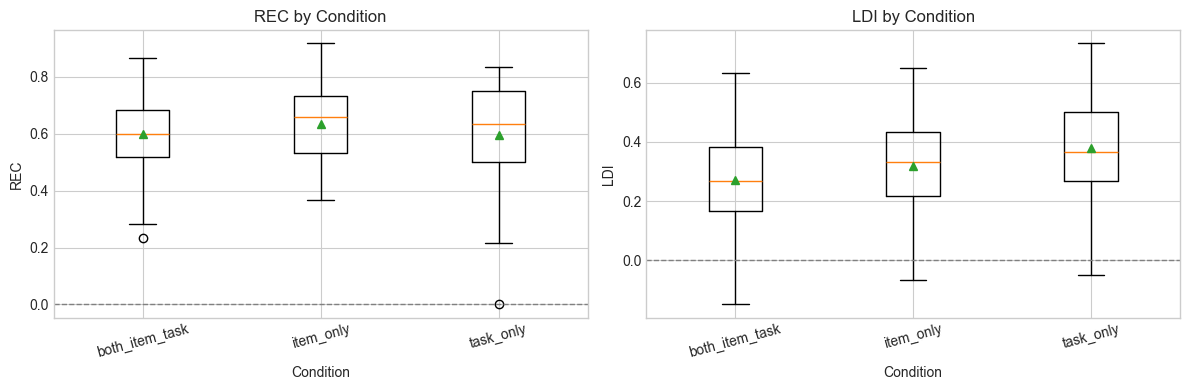

In [5]:
# Visualization: condition-wise distributions for REC and LDI
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cond_order = sorted(global_df["condition"].dropna().unique())

for idx, metric in enumerate(["REC", "LDI"]):
    ax = axes[idx]
    data = [global_df[global_df["condition"] == c][metric].dropna().values for c in cond_order]
    ax.boxplot(data, labels=cond_order, showmeans=True)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_title(f"{metric} by Condition")
    ax.set_xlabel("Condition")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()